In [13]:
import networkx as nx
import pandas as pd
import numpy as np
import psycopg2
import datetime

db_name = "park"

def execute_query(query, *args):
    conn = psycopg2.connect(
        dbname=f"{db_name}",
        user="postgres",
        password="pgpass",
        host="localhost",
        port=5432
    )

    cur = conn.cursor()
    cur.execute(query, *args)
    try:
        result = cur.fetchall()
    except psycopg2.ProgrammingError:
        result = None
    conn.commit()
    conn.close()
    return result

def execute_query_many(query, *args):
    conn = psycopg2.connect(
        dbname=f"{db_name}",
        user="postgres",
        password="pgpass",
        host="localhost",
        port=5432
    )

    cur = conn.cursor()
    cur.executemany(query, *args)
    try:
        result = cur.fetchall()
    except psycopg2.ProgrammingError:
        result = None
    conn.commit()
    conn.close()
    return result

# Simulation metaparameters
price_influence = 4.0
leave_sensitivity = 0.5
distance_scaling = 0.03

min_price = 1
max_price = 100

wealth_probs = [0.5, 0.3, 0.15, 0.05]
cash_targets = [2, 5, 20, 50]

num_attractions = 40
num_guests = 1000

num_days = 2*365

start_date = datetime.date(2024, 10, 20)
end_date = start_date + datetime.timedelta(days=num_days)

In [14]:
# Cleanup previous runs

def cleanup():
    def drop(table):
        try:
            execute_query(f"DROP TABLE {table}")
        except:
            print(f"Failed to delete {table}.")
            pass
    
    drop("transactions")
    drop("attr_summary")
    drop("transactions_old")
    drop("attr_summary_old")
    drop("attractions")
    drop("guests")
cleanup()

In [15]:
# Generates the databases for the park attractions, guests, transaction history, and summary statistics
def generate_park_database(names, num_attractions):
    names = np.random.choice(names, num_attractions, replace=False)

    attraction_categories = ["Roller Coaster", "Merry Go Round", "Food Court", "Go Karts", "Petting Zoo", "Ferris Wheel", "Log Flume", "Slide"]

    def random_attraction(name):
        x = np.random.uniform(0.0, 1.0)
        y = np.random.uniform(0.0, 1.0)
        category = np.random.choice(attraction_categories)
        duration = np.random.uniform(0.05, 1.0)
        max_riders = np.random.randint(5, 10)
        cost = np.random.randint(1, 20)

        return (name, category, max_riders, f"'{duration*15} minutes'", cost, x, y)

    execute_query("""
        CREATE TABLE attractions (
            id SERIAL PRIMARY KEY,
            name VARCHAR(100) NOT NULL,
            category VARCHAR(100),
            max_riders INTEGER,
            duration INTERVAL,
            cost NUMERIC(6, 2) NOT NULL,
            xpos NUMERIC(6, 2) NOT NULL,
            ypos NUMERIC(6, 2) NOT NULL
        );
        """
    )

    # Random attractions
    attractions = [random_attraction(name) for name in names]
    attractions.insert(0, ("Entrance", "Entrance", 1, None, 0.0, 0.5, 0.0))
    
    execute_query_many("""
        INSERT INTO attractions (name, category, max_riders, duration, cost, xpos, ypos)
        VALUES (%s, %s, %s, %s, %s, %s, %s);
    """, attractions)

def generate_guests_database(first_names, last_names, num_guests):
    def random_guest():
        first_name = np.random.choice(first_names)
        last_name = np.random.choice(last_names)
        age = np.random.randint(10, 90)
        wealth = np.random.choice(["low", "medium", "high", "extreme"], p=wealth_probs)
        return (first_name, last_name, age, wealth)
    guests = [random_guest() for _ in range(num_guests)]

    execute_query("""
        CREATE TABLE guests (
            id SERIAL PRIMARY KEY,
            firstname VARCHAR(100) NOT NULL,
            lastname VARCHAR(100) NOT NULL,
            age INTEGER,
            wealth VARCHAR(20)
        );
    """)

    lines = []
    for (first_name, last_name, age, wealth) in guests:
        lines.append(f"(\'{first_name}\', \'{last_name}\', {age}, \'{wealth}\')")
    
    execute_query("INSERT INTO guests (firstname, lastname, age, wealth)\nVALUES\n" + ",\n".join(lines) + ";")


def create_transactions_database(suffix):
    execute_query(f"""
        CREATE TABLE transactions{suffix} (
            id SERIAL PRIMARY KEY,
            guest_id INTEGER NOT NULL REFERENCES guests(id) ON DELETE CASCADE,
            attr_id INTEGER NOT NULL REFERENCES attractions(id) ON DELETE CASCADE,
            amount NUMERIC(6, 2) DEFAULT 0,
            time TIMESTAMP(0) NOT NULL
        );
    """)

def create_summary_database(suffix):
    execute_query(f"""
        CREATE TABLE attr_summary{suffix} (
            date DATE NOT NULL,
            attr_id INTEGER NOT NULL REFERENCES attractions(id) ON DELETE CASCADE,
            total_transactions INTEGER NOT NULL DEFAULT 0,
            total_revenue NUMERIC(10,2) NOT NULL DEFAULT 0,
            price NUMERIC(10, 2) NOT NULL,
            PRIMARY KEY (date, attr_id)
        );
    """)

    execute_query(f"""
        CREATE OR REPLACE FUNCTION update_attr_summary()
        RETURNS TRIGGER AS $$
        BEGIN
            -- Handle INSERT
            IF TG_OP = 'INSERT' THEN
                INSERT INTO attr_summary{suffix}(date, attr_id, total_transactions, total_revenue, price)
                VALUES (DATE(NEW.time), 1, NEW.attr_id, COALESCE(NEW.amount, 0), NEW.price)
                ON CONFLICT (date)
                DO UPDATE
                SET total_transactions = attr_summary{suffix}.total_transactions + 1,
                    total_revenue = attr_summary{suffix}.total_revenue + COALESCE(EXCLUDED.total_revenue, 0);

            -- Handle UPDATE
            ELSIF TG_OP = 'UPDATE' THEN
                -- Subtract the old transaction
                UPDATE attr_summary{suffix}
                SET total_transactions = total_transactions - 1,
                    total_revenue = total_revenue - COALESCE(OLD.amount, 0)
                WHERE date = DATE(OLD.time);

                -- Add the new transaction
                INSERT INTO attr_summary{suffix}(date, attr_id, total_transactions, total_revenue, price)
                VALUES (DATE(NEW.time), 1, NEW.attr_id, COALESCE(NEW.amount, 0), NEW.price)
                ON CONFLICT (date)
                DO UPDATE
                SET total_transactions = attr_summary{suffix}.total_transactions + 1,
                    total_revenue = attr_summary{suffix}.total_revenue + COALESCE(EXCLUDED.total_revenue, 0);

            -- Handle DELETE
            ELSIF TG_OP = 'DELETE' THEN
                UPDATE attr_summary{suffix}
                SET total_transactions = total_transactions - 1,
                    total_revenue = total_revenue - COALESCE(OLD.amount, 0)
                WHERE date = DATE(OLD.time);

                -- Clean up empty or invalid summary rows
                DELETE FROM attr_summary{suffix}
                WHERE total_transactions <= 0 OR total_revenue < 0;
            END IF;

            RETURN NULL;
        END;
        $$ LANGUAGE plpgsql;

        CREATE TRIGGER transactions_summary_trigger
        AFTER INSERT OR UPDATE OR DELETE
        ON transactions{suffix}
        FOR EACH ROW
        EXECUTE FUNCTION update_attr_summary();
    """)

# Setting up database
df = pd.read_csv("rides.csv")
names = df["Attraction Name"].tolist()
generate_park_database(names, num_attractions)

df = pd.read_csv("names.csv")
first_names, last_names = df["First Name"].tolist(), df["Last Name"].tolist()
generate_guests_database(first_names, last_names, num_guests)

create_transactions_database("")
create_summary_database("")

create_transactions_database("_old")
create_summary_database("_old")

In [18]:
def create_park_graph():
    result = execute_query("SELECT id, name, duration, cost, xpos, ypos from attractions;")

    graph = nx.DiGraph()

    for n, (id, name, duration, cost, x, y) in enumerate(result):
        dt = 0.0 if (name == "Entrance") else duration.total_seconds() / (8 * 3600) # Convert to a float representing a fraction of the working day
        graph.add_node(n, pos=np.array([float(x), float(y)]), name=name, cost=float(cost), id=id, duration=dt)
    
    for i in range(len(result)):
        _, _, _, cost1, x1, y1 = result[i]
        for j in range(len(result)):
            if i == j:
                continue
            _, _, _, cost2, x2, y2 = result[j]
            distance = np.sqrt(float(x1 - x2)**2 + float(y1 - y2)**2)
            distance_factor = np.exp(-distance/distance_scaling)
            weight = distance_factor
            graph.add_edge(i, j, weight=weight)
    
    return graph

def float_to_workday_time(f, date):
    start_time = datetime.datetime.combine(date, datetime.time(9, 0))   # 9 AM
    end_time   = datetime.datetime.combine(date, datetime.time(17, 0))  # 5 PM
    delta = end_time - start_time

    result_time = start_time + (1 - f) * delta
    return result_time

def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "fall"


# This function generates a guest's walk through the park. A guest will continue to randomly
# select attractions until they run out of money or the park closes at 5PM, with probabilities
# determined by distance, price, and whether or not the guest visited the attraction recently.
# The guest may also decide to leave early if the price of their next chosen ride is too high.
def random_walk(G, guest_id, date, start, cash_target, time):
    season = get_season(date)

    pos = nx.get_node_attributes(G, "pos")
    costs = nx.get_node_attributes(G, "cost")
    durations = nx.get_node_attributes(G, "duration")
    ids = nx.get_node_attributes(G, "id")

    visited = set()
    path = [start]
    transactions = [(guest_id, ids[start], None, float_to_workday_time(time, date))]

    # Dissatisfaction will accumulate based on if guest cannot find rides close to their cash_target
    dissatisfaction = 0.0

    while True:
        neighbors = [g for g in G.neighbors(path[-1]) if g != 0 and g != path[-1] and g not in visited]
        if not neighbors or time < 0.0: 
            break

        def calculate_weight(target, w):
            price_factor = np.exp(-price_influence * np.abs(cash_target - costs[target])/cash_target)
            
            return w * price_factor

        probs = np.array([calculate_weight(n, G[path[-1]][n]['weight']) for n in neighbors])
        probs /= np.sum(probs)

        next_node = np.random.choice(neighbors, p=probs)
        cost = costs[next_node]
        distance = np.linalg.norm(pos[next_node] - pos[path[-1]])
        duration = durations[next_node]

        dissatisfaction += leave_sensitivity * np.abs(cash_target - cost) / cash_target
        if dissatisfaction > 1.0:
            break

        path.append(next_node)
        speed = 0.1 if season != 'winter' else 0.1
        dt = distance * speed + duration
        time -= dt
        current_time = float_to_workday_time(time, date)
        transactions.append((guest_id, ids[next_node], cost, current_time))

        visited.add(next_node)

    return transactions

# Simulates a day of guests visiting the park. Every guest has a fixed amount of cash depending
# on their wealth, and the number of guests that show up depend on the season and weekday.
def simulate_day(date, num_guests, suffix=""):
    result = np.array(execute_query("SELECT id, age, wealth FROM guests;"))

    idx = np.random.choice(range(len(result)), num_guests, replace=False)
    guests = result[idx]

    graph = create_park_graph()
    conn = psycopg2.connect(
        dbname=f"{db_name}",
        user="postgres",
        password="pgpass",
        host="localhost",
        port=5432
    )

    cur = conn.cursor()

    # Turn off transaction summary trigger while data is being dumped
    cur.execute(f"ALTER TABLE transactions{suffix} DISABLE TRIGGER transactions_summary_trigger;")

    for (id, age, wealth) in guests:
        start_time = np.random.uniform(0.5, 1.0) # Arrive uniformly between open (9AM) and halfway through the workday (1PM)
        if wealth == "low":
            cash_target = cash_targets[0]
        elif wealth == "medium":
            cash_target = cash_targets[1]
        elif wealth == "high":
            cash_target = cash_targets[2]
        elif wealth == "extreme":
            cash_target = cash_targets[3]
        transactions = random_walk(graph, id, date, 0, cash_target, start_time)

        cur.executemany(f"""
            INSERT INTO transactions{suffix} (guest_id, attr_id, amount, time) VALUES (%s, %s, %s, %s);
        """, transactions)

    # Update summary table and turn trigger back on
    cur.execute(f"ALTER TABLE transactions{suffix} ENABLE TRIGGER transactions_summary_trigger;")
    cur.execute(f"""
        INSERT INTO attr_summary{suffix} (date, attr_id, total_transactions, total_revenue, price)
        SELECT d.day, a.id,
            COALESCE(t.total_transactions, 0),
            COALESCE(t.total_revenue, 0),
            a.cost  -- use the current ride price from attractions
        FROM (SELECT %s::date AS day) AS d
        CROSS JOIN attractions AS a
        LEFT JOIN (
            SELECT attr_id,
                COUNT(*) AS total_transactions,
                SUM(amount) AS total_revenue
            FROM transactions{suffix}
            WHERE DATE(time) = %s
            GROUP BY attr_id
        ) AS t
        ON a.id = t.attr_id
        ON CONFLICT (date, attr_id)
        DO UPDATE
        SET total_transactions = EXCLUDED.total_transactions,
            total_revenue = EXCLUDED.total_revenue,
            price = EXCLUDED.price;
    """, (date, date))
    conn.commit()
    conn.close()

def sample_num_guests(date):
    season = get_season(date)
    
    if season == "winter":
        base = 20
    elif season == "spring":
        base = 40
    elif season == "summer":
        base = 60
    elif season == "fall":
        base = 30
    

    if date.weekday() >= 5:  # Saturday or Sunday
        base *= 1.5 # more guests on weekends
    else:
        base *= 1.0
    
    # Add some randomness
    guests = int(np.random.normal(base, base * 0.3))

    base = 30
    guests = base
    
    return max(0, guests)

In [19]:
# Do a control run, where no optimization is performed. 
current_date = start_date
while current_date <= end_date:
    simulate_day(current_date, sample_num_guests(current_date), suffix="_old")
    current_date += datetime.timedelta(days=1)

In [20]:
def adjust_prices(costs):
    ids, = zip(*execute_query("SELECT id FROM attractions;"))
    values = ",".join([f"({i}, {c})" for i,c in zip(ids, costs)])

    execute_query(f"""
        UPDATE attractions
        SET cost = data.new_cost
        FROM (VALUES {values}) as data(id, new_cost)
        WHERE attractions.id = data.id;
    """)

current_date = start_date

In [21]:
# Do a run with an online Bayesian optimizer acting on the attraction prices
from skopt import forest_minimize

current_date = start_date

def simulate_and_get_revenue(prices):
    global current_date
    adjust_prices(prices)
    simulate_day(current_date, sample_num_guests(current_date))
    print(f"Calling simulate_day({current_date})")
    total_revenue = float(execute_query(
        "SELECT SUM(total_revenue) FROM attr_summary WHERE date = %s;",
        (current_date,)
    )[0][0])
    current_date += datetime.timedelta(days=1)
    return -total_revenue

num_attractions = execute_query("SELECT COUNT(*) FROM attractions;")[0][0]
bounds = [(min_price, max_price)]*num_attractions
res = forest_minimize(simulate_and_get_revenue, bounds, base_estimator="RF", n_calls=num_days, n_random_starts=10)
print(res)

Calling simulate_day(2024-10-20)
Calling simulate_day(2024-10-21)
Calling simulate_day(2024-10-22)
Calling simulate_day(2024-10-23)
Calling simulate_day(2024-10-24)
Calling simulate_day(2024-10-25)
Calling simulate_day(2024-10-26)
Calling simulate_day(2024-10-27)
Calling simulate_day(2024-10-28)
Calling simulate_day(2024-10-29)
Calling simulate_day(2024-10-30)
Calling simulate_day(2024-10-31)
Calling simulate_day(2024-11-01)
Calling simulate_day(2024-11-02)
Calling simulate_day(2024-11-03)
Calling simulate_day(2024-11-04)
Calling simulate_day(2024-11-05)
Calling simulate_day(2024-11-06)
Calling simulate_day(2024-11-07)
Calling simulate_day(2024-11-08)
Calling simulate_day(2024-11-09)
Calling simulate_day(2024-11-10)
Calling simulate_day(2024-11-11)
Calling simulate_day(2024-11-12)
Calling simulate_day(2024-11-13)
Calling simulate_day(2024-11-14)
Calling simulate_day(2024-11-15)
Calling simulate_day(2024-11-16)
Calling simulate_day(2024-11-17)
Calling simulate_day(2024-11-18)
Calling si

1170.0


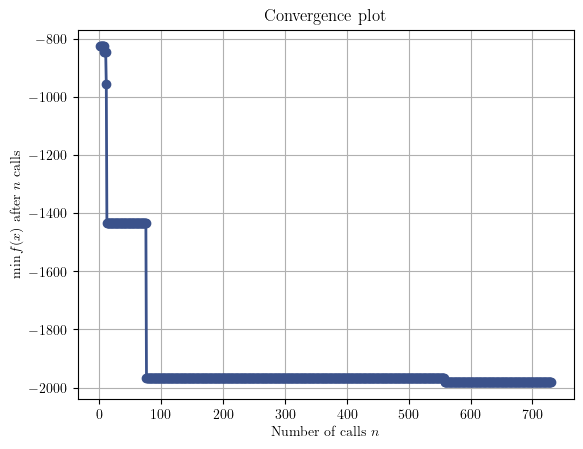

In [29]:
from skopt.plots import plot_convergence

plot_convergence(res)
total_revenue = float(execute_query(
    "SELECT SUM(total_revenue) FROM attr_summary WHERE date = %s;",
    (current_date - datetime.timedelta(days=1),)
)[0][0])